# Straight-Walk Segment ZV Comparison

This notebook runs pyshoe-based zero-velocity detection on the previously segmented straight-walk bouts, then compares the reconstructed trajectory and traveled distance against the synced OptiTrack ankle marker.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

NOTEBOOK_DIR = Path.cwd().resolve()
# if not (NOTEBOOK_DIR / "ins_tools").exists():
#     for candidate in [
#         Path.cwd().resolve() / "pyshoe_CSH",
#         Path.cwd().resolve().parent / "pyshoe_CSH",
#     ]:
#         if (candidate / "ins_tools").exists():
#             NOTEBOOK_DIR = candidate
#             break
#     else:
#         raise FileNotFoundError("Could not locate pyshoe_CSH from the current working directory.")

PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

DATA_DIR = PROJECT_ROOT / "data" / "optitrack_imu" / "0320_14_54"
SEGMENTS_DIR = DATA_DIR / "straight_walk_segments"
SUMMARY_PATH = DATA_DIR / "straight_walk_segments_summary.csv"
ATTITUDE_SOURCE = "gyro_integrated"
# ATTITUDE_SOURCE = "measured_quat"
QUAT_MODE = "direct"
RESULTS_DIR = NOTEBOOK_DIR / "results" / f"segment_zv_compare_0320_14_54_{ATTITUDE_SOURCE}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DETECTOR_GRIDS = {
    "shoe": np.geomspace(1e4, 3e7, 12),
    "ared": np.linspace(0.1, 4.0, 12),
}
WINDOW_SIZE = 5
SIGMA_A = 0.01
SIGMA_W_DPS = 0.1
ALIGN_DIST_M = 0.8
TIME_COLUMN = "time_synced_to_imu"

print(f"DATA_DIR: {DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"ATTITUDE_SOURCE: {ATTITUDE_SOURCE}, QUAT_MODE: {QUAT_MODE}")


DATA_DIR: /home/user/soccer_analysis/data/optitrack_imu/0320_14_54
RESULTS_DIR: /home/user/soccer_analysis/pyshoe_CSH/results/segment_zv_compare_0320_14_54_gyro_integrated
ATTITUDE_SOURCE: gyro_integrated, QUAT_MODE: direct


In [ ]:
from segment_zv_compare import (
    analyze_segment,
    discover_segments,
    export_best_run_details,
    plot_all_segment_overlays,
    plot_metric_summary,
    plot_segment_detail,
    select_best_per_segment,
    summarize_best_results,
    sweep_all_segments,
)


In [ ]:
segment_table = discover_segments(SUMMARY_PATH, SEGMENTS_DIR)
metrics_df = sweep_all_segments(
    segment_table=segment_table,
    detector_grids=DETECTOR_GRIDS,
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
)
metrics_df["abs_path_xy_error_m"] = metrics_df["path_xy_error_m"].abs()
metrics_df["abs_disp_xy_error_m"] = metrics_df["disp_xy_error_m"].abs()

best_df = select_best_per_segment(metrics_df, metric="armse_2d_m")
summary_df = summarize_best_results(best_df)

metrics_df.to_csv(RESULTS_DIR / "threshold_sweep.csv", index=False)
best_df.to_csv(RESULTS_DIR / "best_segment_metrics.csv", index=False)
export_best_run_details(
    best_df=best_df,
    segment_table=segment_table,
    output_dir=RESULTS_DIR / "best_run_details",
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
)

display(
    best_df[
        [
            "segment_id",
            "direction_label",
            "detector",
            "threshold",
            "armse_2d_m",
            "endpoint_xy_error_m",
            "est_path_xy_m",
            "gt_path_xy_m",
            "path_xy_error_m",
            "zv_ratio",
        ]
    ].round(3)
)
display(summary_df.round(3))


,segment_id,direction_label,detector,threshold,armse_2d_m,endpoint_xy_error_m,est_path_xy_m,gt_path_xy_m,path_xy_error_m,zv_ratio
0,1,positive,shoe,380635.825,0.458,1.270,12.402,4.076,8.325,0.391
1,2,negative,ared,1.164,0.332,0.880,5.378,3.520,1.858,0.461
2,3,positive,ared,1.164,0.401,1.097,7.533,3.544,3.989,0.410
3,4,negative,shoe,183826.335,0.775,2.692,13.423,3.511,9.912,0.339
4,5,positive,shoe,788154.925,0.438,0.969,5.696,3.510,2.186,0.470
5,6,negative,ared,0.809,0.318,0.197,9.738,3.521,6.217,0.374
6,7,positive,ared,3.291,0.923,2.313,5.869,3.532,2.337,0.555
7,8,negative,ared,1.164,0.356,1.312,9.725,3.412,6.313,0.517
8,9,positive,ared,0.809,0.215,0.680,5.552,3.438,2.114,0.475
9,10,negative,ared,0.455,0.233,0.605,6.688,3.370,3.318,0.402


,num_segments,mean_armse_2d_m,median_armse_2d_m,mean_endpoint_xy_error_m,mean_abs_path_xy_error_m,mean_abs_disp_xy_error_m,count_ared,count_shoe
0,12,0.421,0.344,1.19,4.875,0.58,8,4


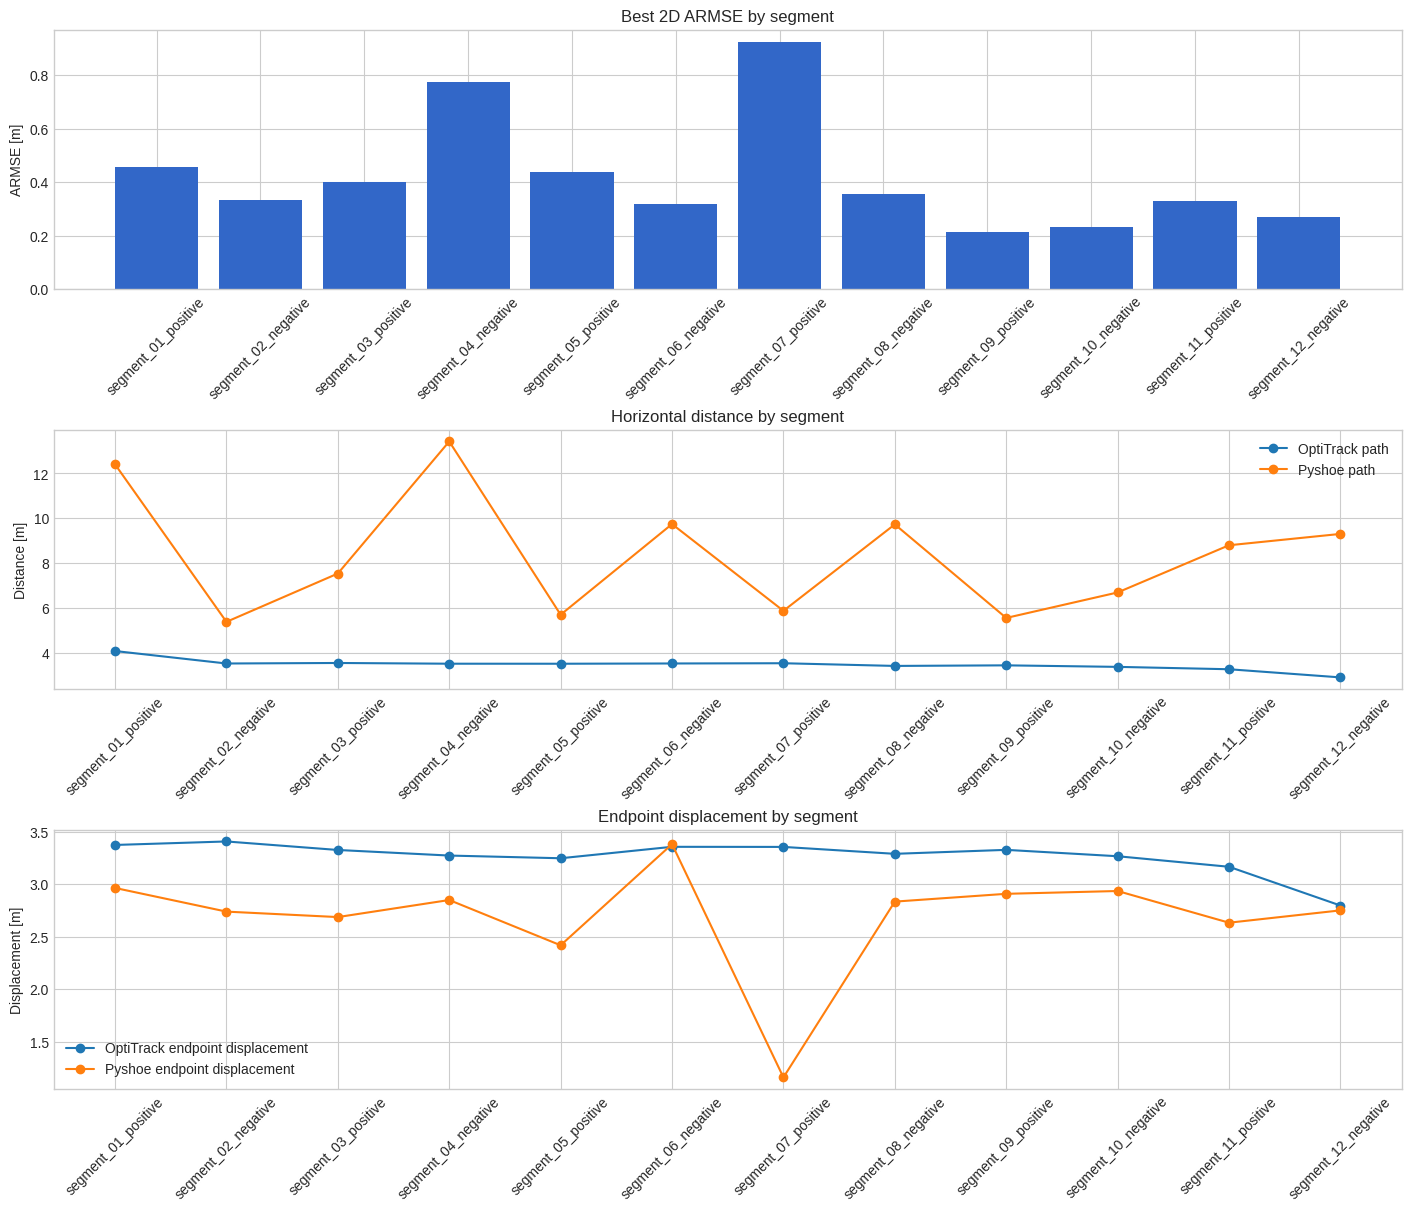

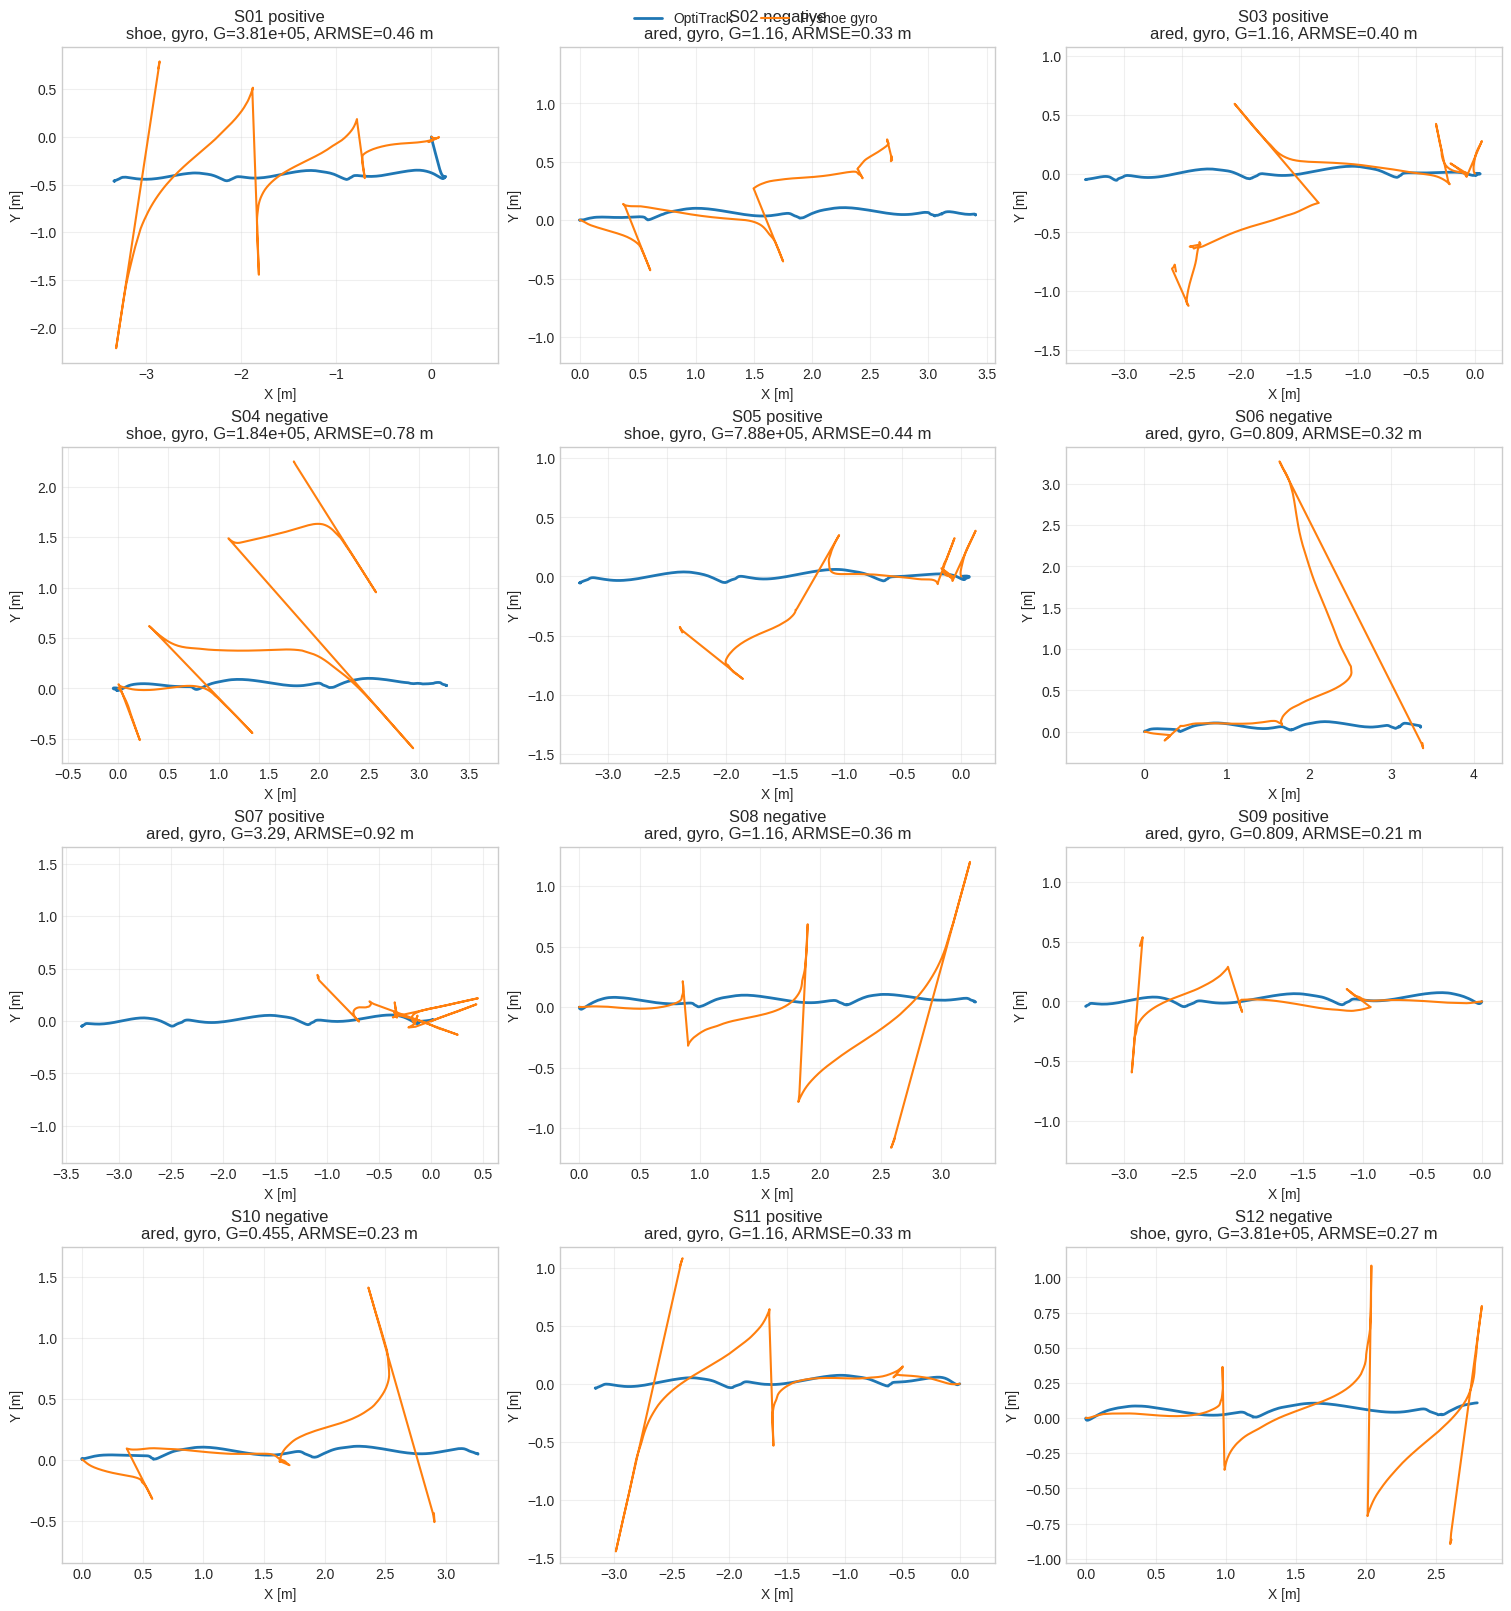

In [ ]:
fig, axes = plot_metric_summary(best_df)
plt.show()

fig, axes = plot_all_segment_overlays(
    best_df=best_df,
    segment_table=segment_table,
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    cols=3,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
)
plt.show()


,segment_id,direction_label,segment_name,detector,threshold,attitude_source,quat_mode,num_samples,duration_s,zv_count,...,endpoint_3d_error_m,est_path_xy_m,gt_path_xy_m,path_xy_error_m,est_disp_xy_m,gt_disp_xy_m,disp_xy_error_m,est_path_3d_m,gt_path_3d_m,path_3d_error_m
0,3,positive,segment_03_positive,ared,1.164,gyro_integrated,,517,5.25,212,...,1.106,7.533,3.544,3.989,2.686,3.325,-0.638,7.848,4.136,3.712


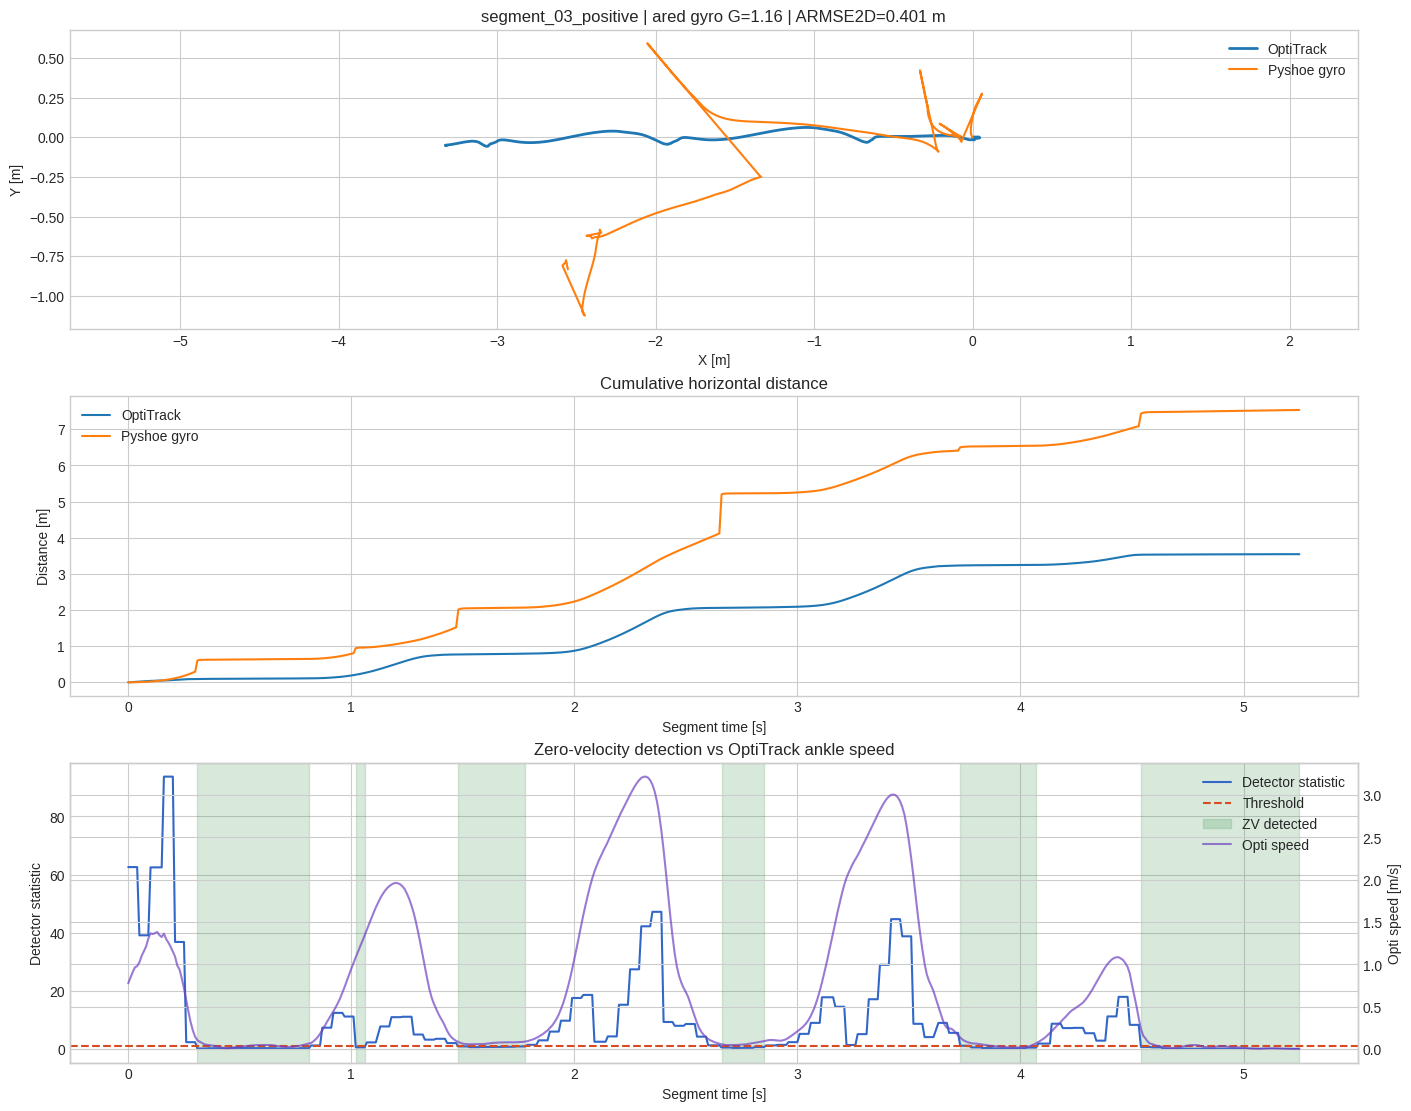

,segment_time_s,imu_time,lrt,zv_detected,opti_speed_mps,est_x_m,est_y_m,est_z_m,est_x_aligned_m,est_y_aligned_m,est_z_aligned_m,gt_x_m,gt_y_m,gt_z_m,est_cumdist_xy_m,gt_cumdist_xy_m,est_cumdist_3d_m,gt_cumdist_3d_m
0,0.00,16.89,62.59038,0,0.778479,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.01,16.90,62.59038,0,0.844318,0.000152,-0.000320,-0.000141,-0.000137,0.000327,-0.000141,0.003016,0.000578,-0.008141,0.000354,0.003071,0.000381,0.008701
2,0.02,16.91,62.59038,0,0.908960,0.000510,-0.000864,-0.000469,-0.000467,0.000888,-0.000469,0.006283,0.001098,-0.016696,0.001005,0.006379,0.001111,0.017874
3,0.03,16.92,62.59038,0,0.965642,0.001143,-0.001665,-0.001054,-0.001061,0.001719,-0.001054,0.009971,0.001605,-0.025851,0.002027,0.010102,0.002287,0.027756
4,0.04,16.93,62.59038,0,0.981199,0.002030,-0.002755,-0.001863,-0.001893,0.002851,-0.001863,0.013767,0.001851,-0.035149,0.003431,0.013906,0.003908,0.037802


In [ ]:
SEGMENT_TO_PLOT = 3

selected_metrics = best_df.loc[best_df["segment_id"] == SEGMENT_TO_PLOT].iloc[0]
selected_segment = segment_table.loc[segment_table["segment_id"] == SEGMENT_TO_PLOT].iloc[0]

selected_metrics_dict, selected_detail_df = analyze_segment(
    imu_path=selected_segment["imu_path"],
    opti_path=selected_segment["opti_path"],
    segment_id=int(selected_metrics["segment_id"]),
    direction_label=selected_metrics["direction_label"],
    detector=selected_metrics["detector"],
    threshold=float(selected_metrics["threshold"]),
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
)

selected_detail_df.to_csv(
    RESULTS_DIR / f"{selected_metrics_dict['segment_name']}_{selected_metrics_dict['detector']}_{ATTITUDE_SOURCE}_detail_selected.csv",
    index=False,
)

display(pd.DataFrame([selected_metrics_dict]).round(3))
fig, axes = plot_segment_detail(selected_detail_df, selected_metrics_dict)
plt.show()
display(selected_detail_df.head())


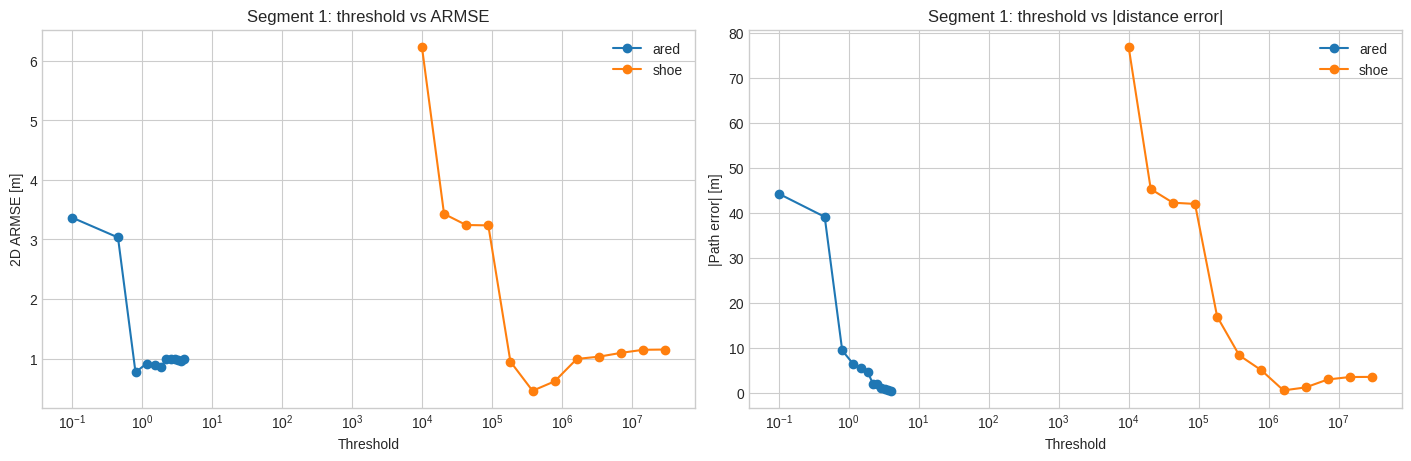

In [ ]:
segment_sweep = metrics_df.loc[metrics_df["segment_id"] == SEGMENT_TO_PLOT].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for detector, group in segment_sweep.groupby("detector"):
    group = group.sort_values("threshold")
    axes[0].plot(group["threshold"], group["armse_2d_m"], marker="o", label=detector)
    axes[1].plot(group["threshold"], group["abs_path_xy_error_m"], marker="o", label=detector)

axes[0].set_xscale("log")
axes[0].set_title(f"Segment {SEGMENT_TO_PLOT}: threshold vs ARMSE")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("2D ARMSE [m]")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_title(f"Segment {SEGMENT_TO_PLOT}: threshold vs |distance error|")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("|Path error| [m]")
axes[1].legend()

plt.show()
